Notebook dedicated to LDA modeling and topic selection.

In [ ]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

from wordcloud import WordCloud

sys.path.append("../")

In [ ]:
ds = load_dataset("samchain/bis_central_bank_speeches", split="train")
df = ds.to_pandas()

In [63]:
df = pd.read_pickle("../data/preprocessed/df_preprocessed_CB_corpus.pkl")

In [64]:
print(df.shape)
print(df.columns)
print(df["text_final"].isna().sum())

(19170, 12)
Index(['description', 'text', 'bank', 'Year', 'Month', 'text_length',
       'clean_text', 'tokens', 'tokens_clean', 'tokens_lemma', 'tokens_final',
       'text_final'],
      dtype='str')
0


In [90]:
tf_vectorizer = CountVectorizer(
    max_features=5000,
    min_df=20,
    max_df=0.55)
tf = tf_vectorizer.fit_transform(df["text_final"])

In [92]:
word_counts = np.asarray(tf.sum(axis=0)).flatten()
words = tf_vectorizer.get_feature_names_out()
top_indices = word_counts.argsort()[::-1]
top_words = [(words[i], word_counts[i]) for i in top_indices[:20]]
top_words

[('inflation', np.int64(137528)),
 ('reserve', np.int64(55501)),
 ('euro_area', np.int64(49787)),
 ('target', np.int64(45745)),
 ('asset', np.int64(45107)),
 ('fund', np.int64(40889)),
 ('firm', np.int64(39444)),
 ('management', np.int64(39281)),
 ('debt', np.int64(38003)),
 ('liquidity', np.int64(37360)),
 ('cent', np.int64(36146)),
 ('loan', np.int64(35460)),
 ('fiscal', np.int64(34029)),
 ('framework', np.int64(33481)),
 ('payment', np.int64(32986)),
 ('money', np.int64(32601)),
 ('industry', np.int64(31493)),
 ('trade', np.int64(31282)),
 ('decision', np.int64(30916)),
 ('decline', np.int64(30541))]

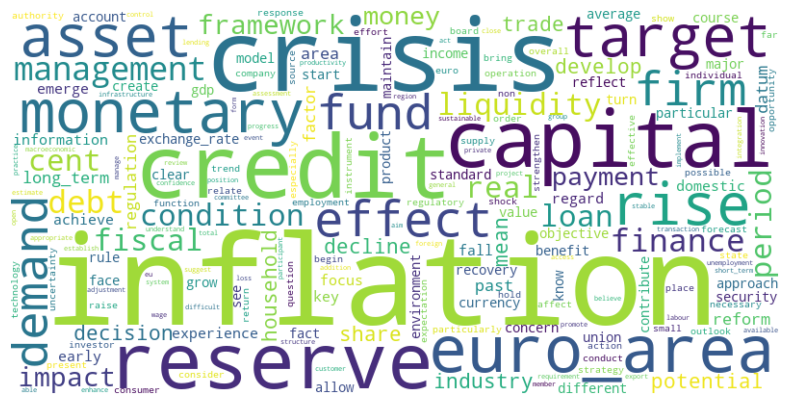

In [70]:
word_counts = np.asarray(tf.sum(axis=0)).flatten()
words = tf_vectorizer.get_feature_names_out()
freq_dict = dict(zip(words, word_counts))
wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freq_dict)
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [72]:
print(type(df["tokens_final"].iloc[0]))
print(df["tokens_final"].iloc[0][:5])

<class 'list'>
['tietmeyer', 'consider', 'monetary', 'integration', 'implication']


LDA coherence for k=5, metric=u_mass: -0.7357410343251981
LDA coherence for k=5, metric=c_v: 0.4122337974144056
LDA coherence for k=5, metric=c_uci: 0.12991376262160942
LDA coherence for k=5, metric=c_npmi: 0.020764567115246428
LDA coherence for k=10, metric=u_mass: -0.7940155747705069
LDA coherence for k=10, metric=c_v: 0.4864545973737986
LDA coherence for k=10, metric=c_uci: 0.3047479421030484
LDA coherence for k=10, metric=c_npmi: 0.03949135469100717
LDA coherence for k=15, metric=u_mass: -0.8530573041219706
LDA coherence for k=15, metric=c_v: 0.47550228342576173
LDA coherence for k=15, metric=c_uci: 0.315124885720914
LDA coherence for k=15, metric=c_npmi: 0.03952493465756161
LDA coherence for k=17, metric=u_mass: -0.8444632130672642
LDA coherence for k=17, metric=c_v: 0.48532069397745314
LDA coherence for k=17, metric=c_uci: 0.34882864514514894
LDA coherence for k=17, metric=c_npmi: 0.043253949348445946
LDA coherence for k=20, metric=u_mass: -0.8870420388128502
LDA coherence for k=

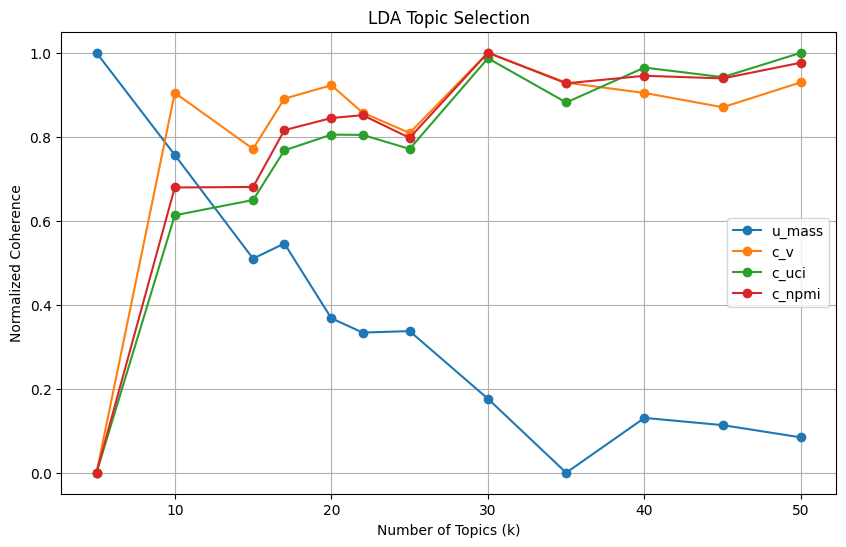

In [ ]:
#From course material: LDA topic selection using multiple coherence metrics 
# (u_mass, c_v, c_uci, c_npmi) over a range of topic numbers, with normalization for comparison.

tokenized_texts = df["tokens_final"].tolist()
dictionary = Dictionary(tokenized_texts)
dictionary.filter_extremes(no_below=20, no_above=0.8)

def get_topics_lda(model, feature_names, n_top_words):
    topics = []
    for topic in model.components_:
        top_idx = np.argsort(-topic)[:n_top_words]
        topics.append([feature_names[i] for i in top_idx])
    return topics

feature_names = tf_vectorizer.get_feature_names_out()

topic_range = [5, 10, 15, 17, 20, 22, 25, 30, 35, 40, 45, 50]
coherence_metrics = ['u_mass', 'c_v', 'c_uci', 'c_npmi']
results = {m: {} for m in coherence_metrics}

for k in topic_range:
    lda = LatentDirichletAllocation(n_components=k, random_state=42)
    lda.fit(tf)

    topics = get_topics_lda(lda, feature_names, 20)

    for met in coherence_metrics:
        cm = CoherenceModel(
            topics=topics,
            texts=tokenized_texts,
            dictionary=dictionary,
            coherence=met
        )
        score = cm.get_coherence()
        results[met][k] = score
        print(f"LDA coherence for k={k}, metric={met}: {score}")

plt.figure(figsize=(10,6))

for met in coherence_metrics:
    ks = sorted(results[met].keys())
    scores = np.array([results[met][k] for k in ks])
    norm = (scores - scores.min()) / (scores.max() - scores.min())
    plt.plot(ks, norm, marker='o', label=met)

plt.xlabel("Number of topics K")
plt.ylabel("Normalized coherence")
plt.title("LDA topic selection")
plt.legend()
plt.grid(True)
plt.show()

In [126]:
def plot_top_words_by_pairs(model, vectorizer, n_top_words, title):
    feature_names = vectorizer.get_feature_names_out()
    n_topics = model.components_.shape[0]

    for i in range(0, n_topics, 2):
        fig, axes = plt.subplots(2, 1, figsize=(10, 8))

        for j in range(2):
            if i + j >= n_topics:
                axes[j].axis("off")
                continue

            topic = model.components_[i + j]
            top_features_ind = topic.argsort()[-n_top_words:]
            top_features = feature_names[top_features_ind]
            weights = topic[top_features_ind]

            ax = axes[j]
            ax.barh(top_features, weights, height=0.7)
            ax.set_title(f"Topic {i + j + 1}", fontsize=14)
            ax.tick_params(axis="both", labelsize=10)

            for spine in ["top", "right", "left"]:
                ax.spines[spine].set_visible(False)

        plt.suptitle(f"{title} ({i+1}-{min(i+2, n_topics)})", fontsize=16)
        plt.tight_layout()
        plt.show()

In [93]:
lda = LatentDirichletAllocation(
    n_components=17,
    random_state=0
)

lda.fit(tf)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",17
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


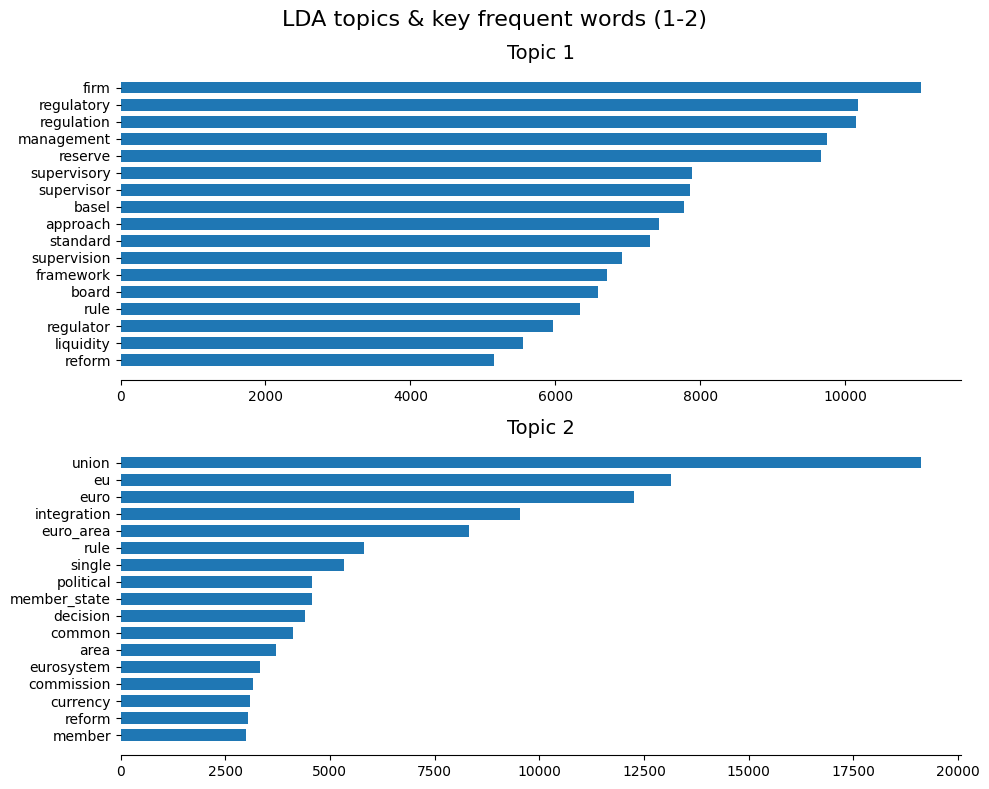

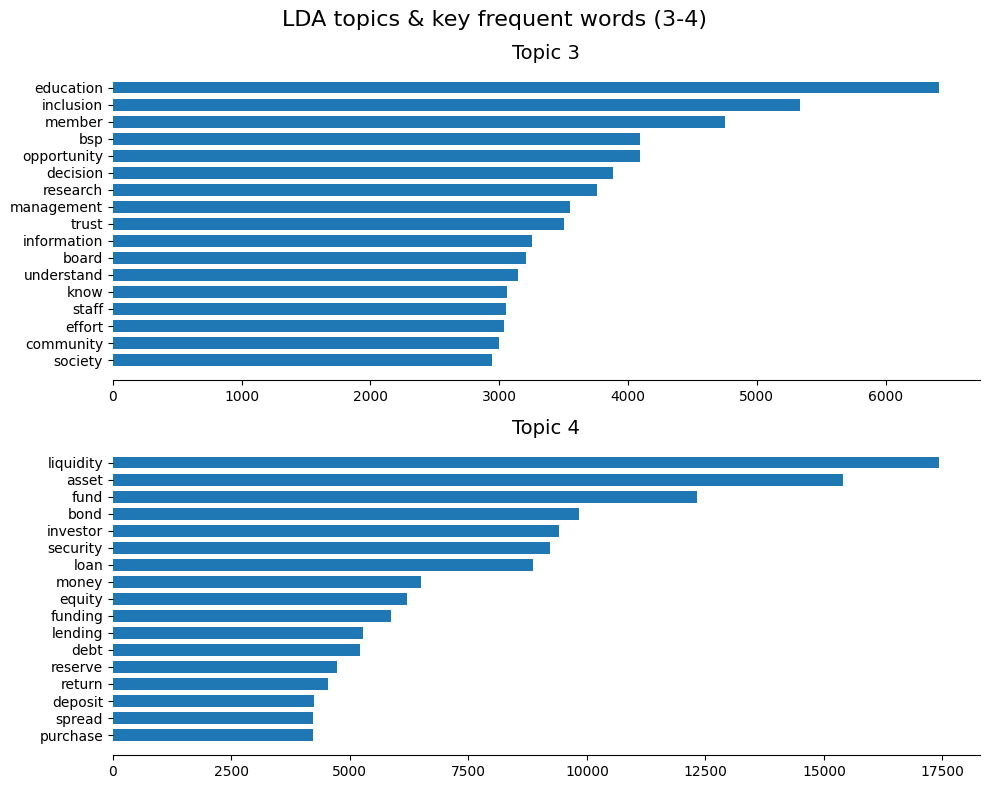

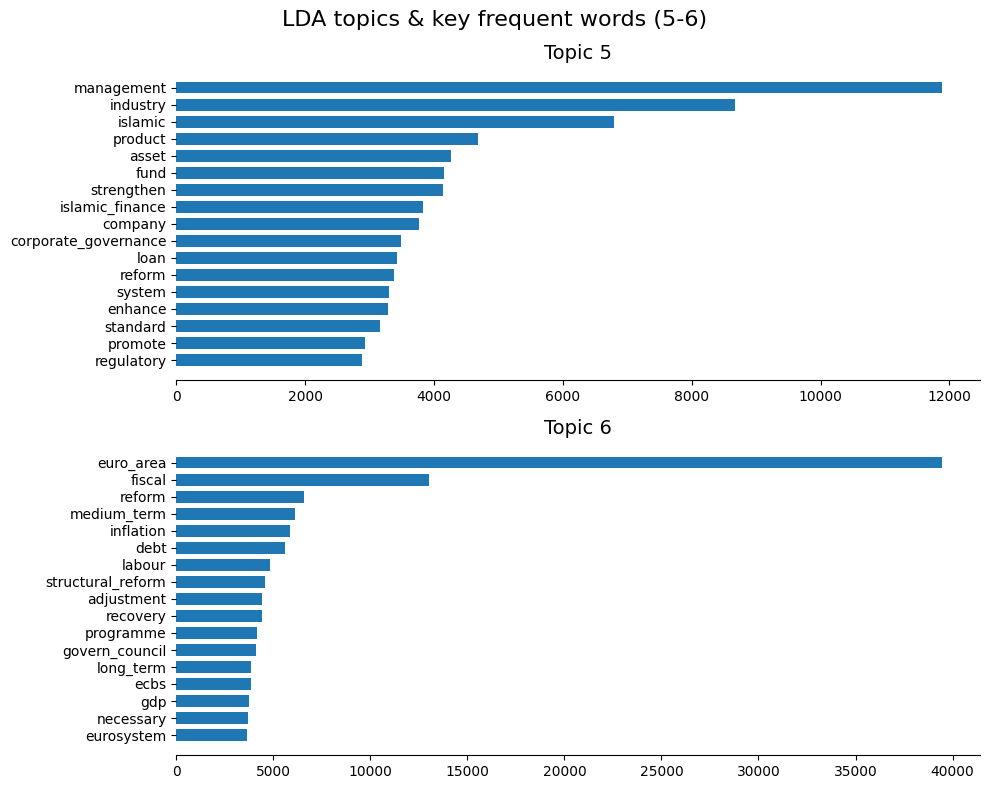

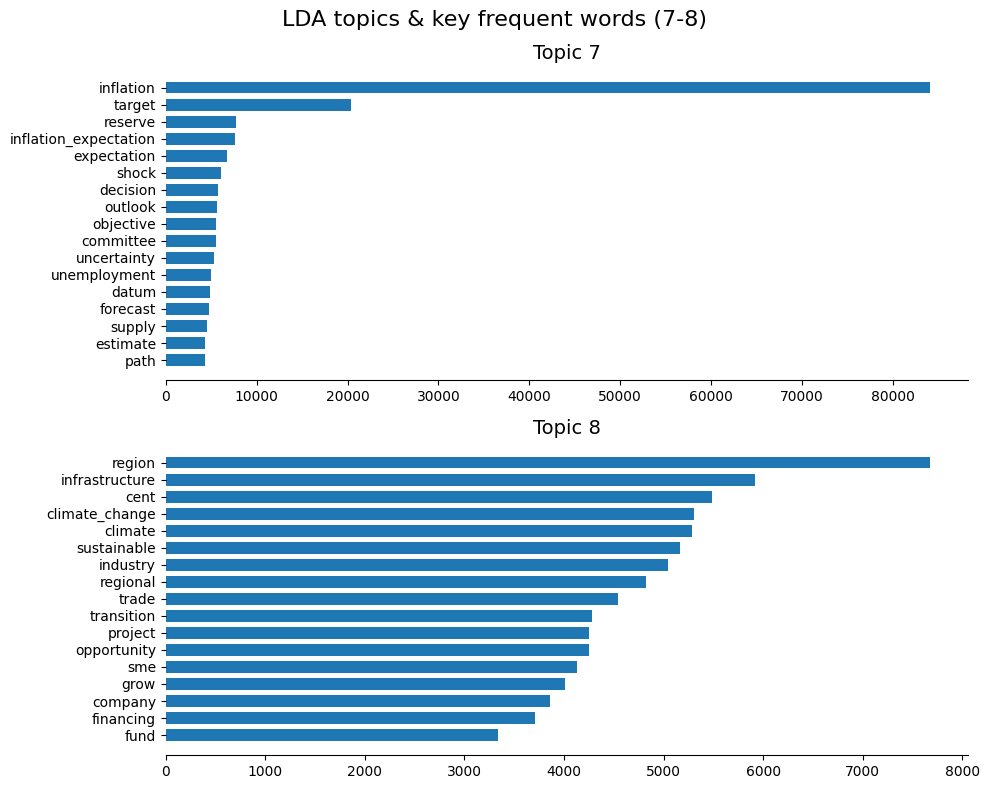

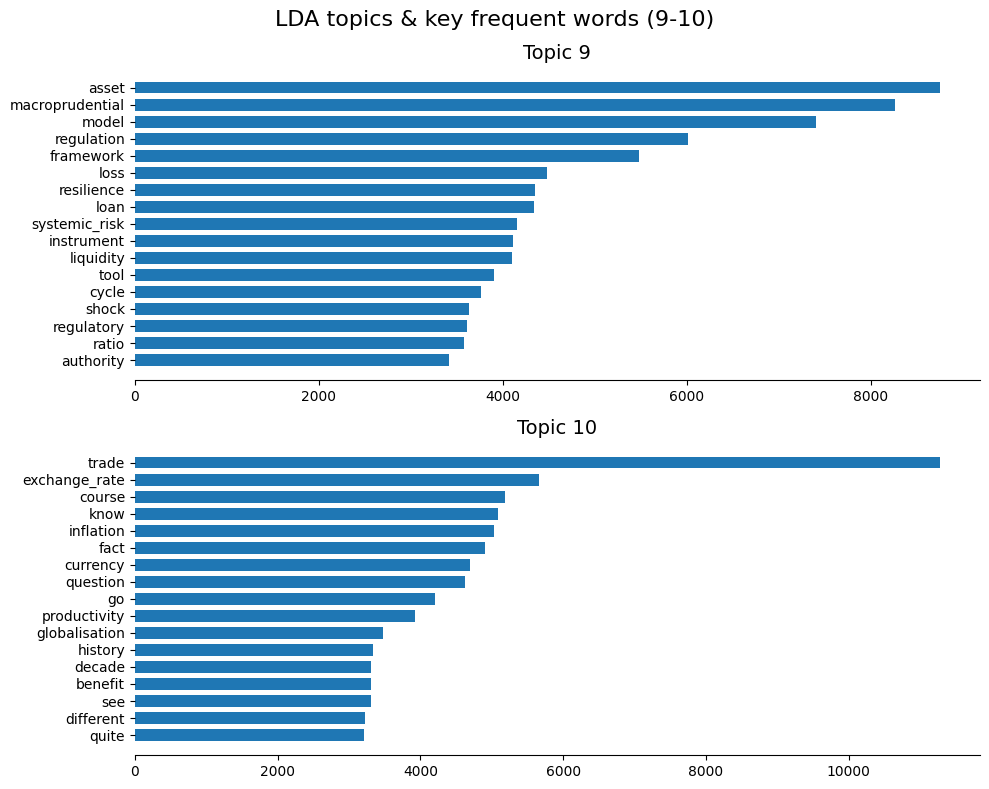

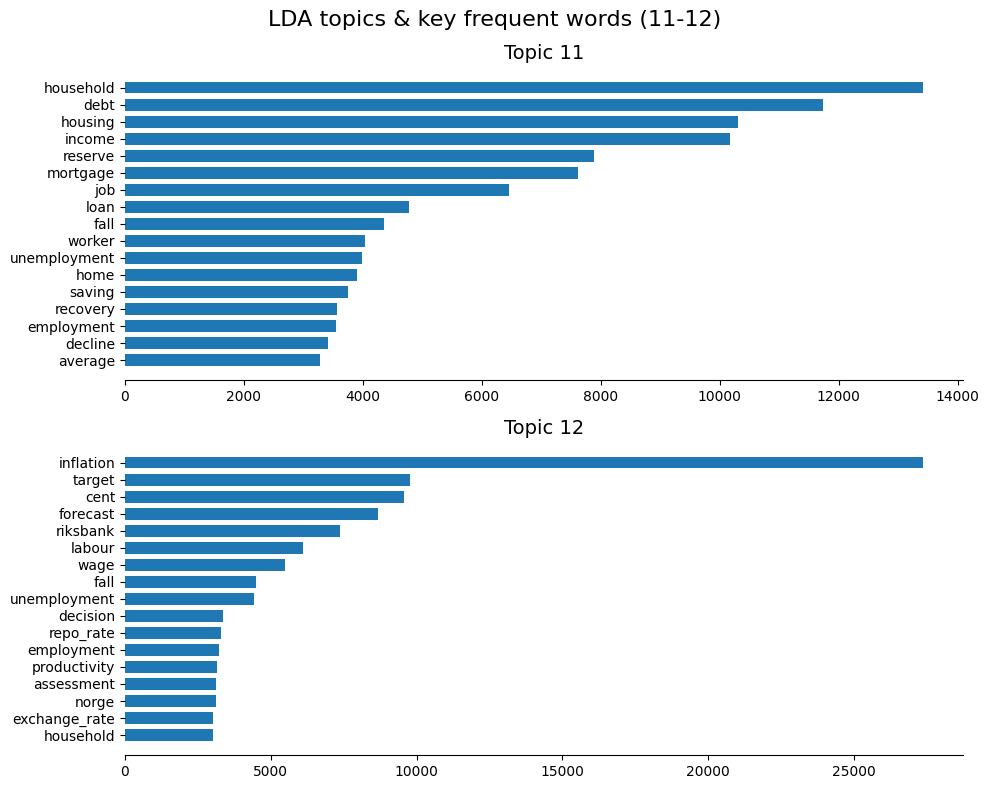

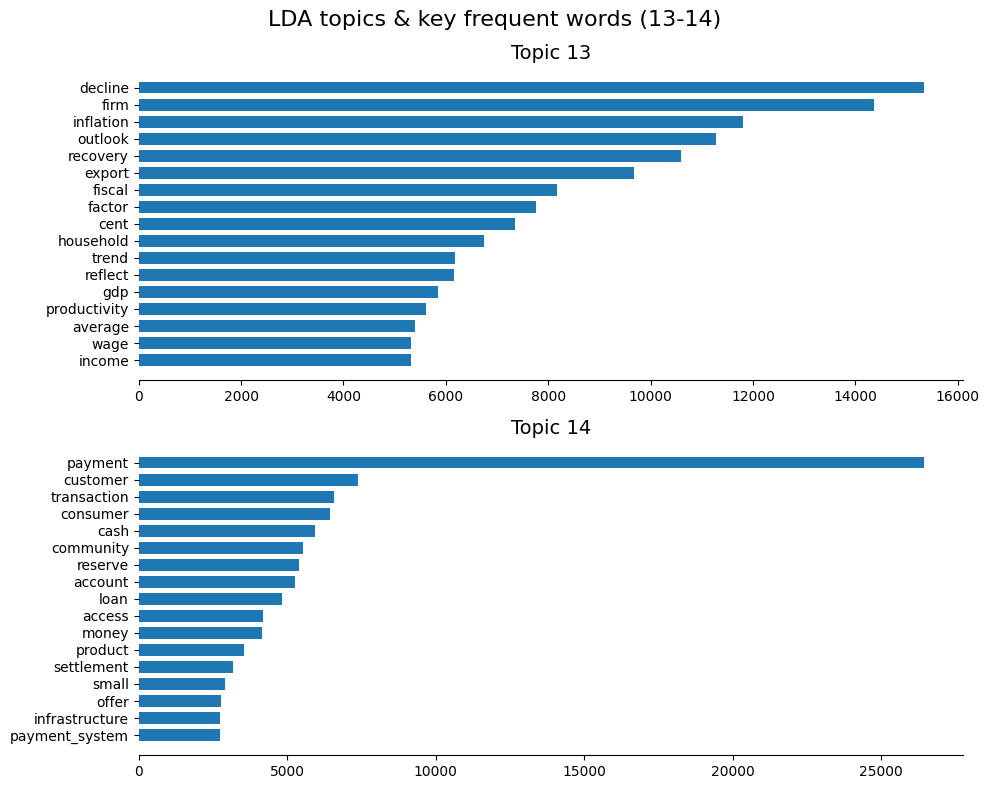

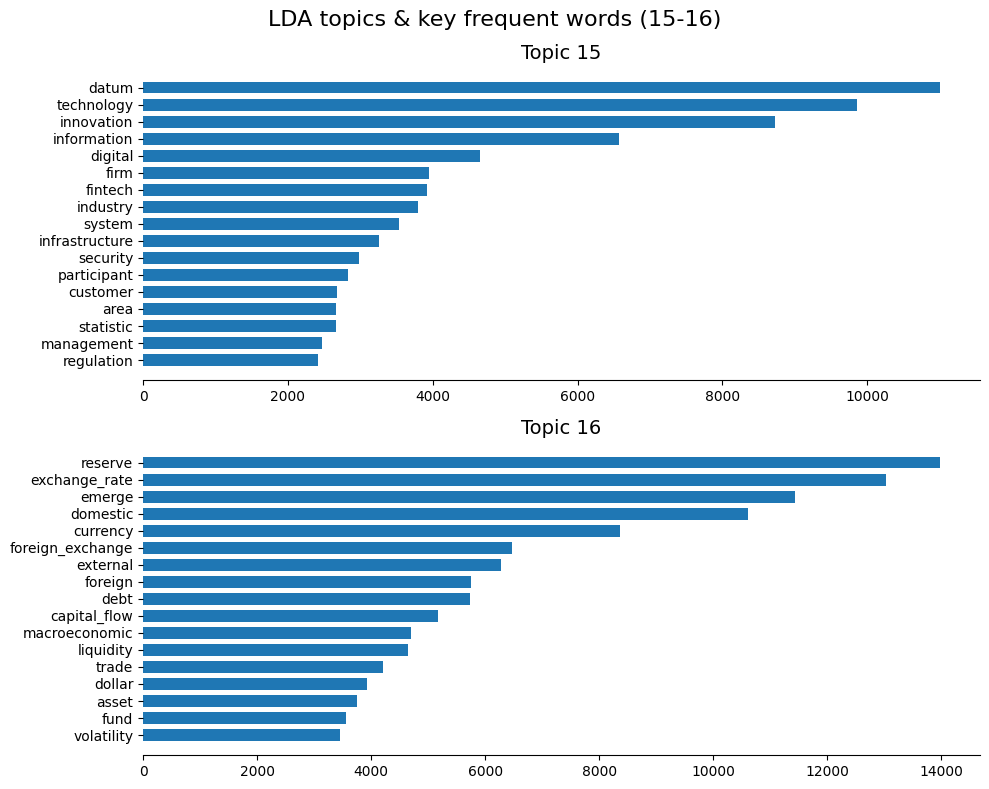

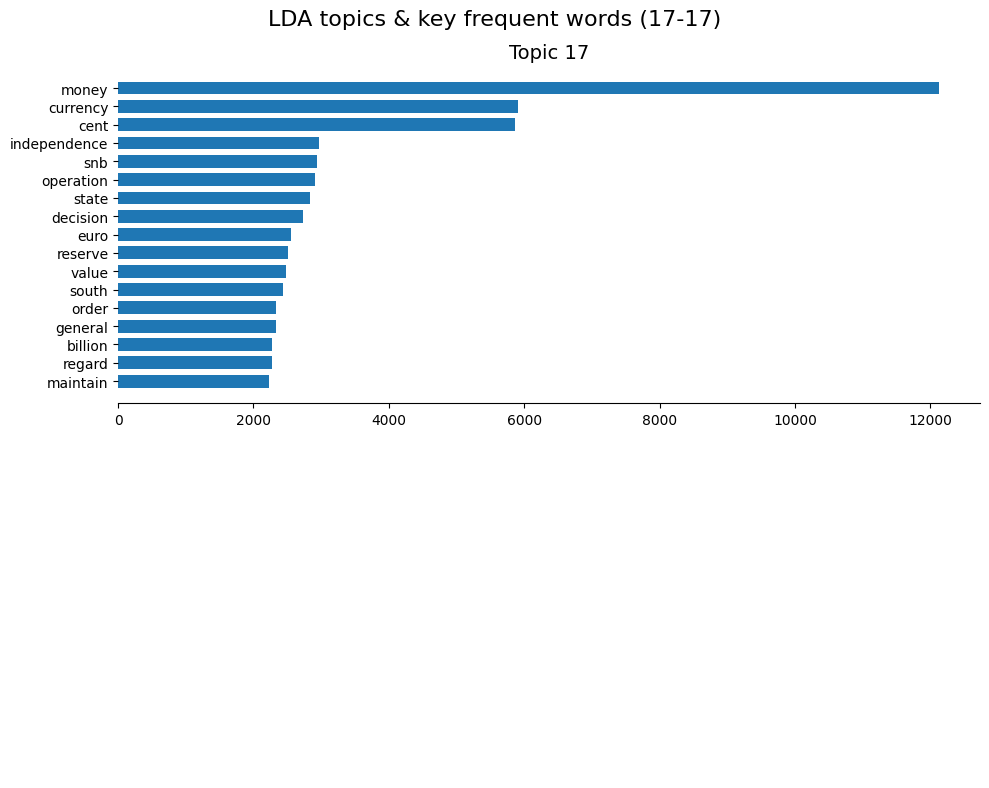

In [129]:
plot_top_words_by_pairs(lda, tf_vectorizer, 17, "LDA topics & key frequent words")

In [99]:
def get_topics_lda(model, feature_names, n_top_words=15):
    topics = []
    for topic in model.components_:
        top_idx = topic.argsort()[-n_top_words:][::-1]
        topics.append([feature_names[i] for i in top_idx])
    return topics

topics = get_topics_lda(lda, tf_vectorizer.get_feature_names_out(), 15)

for i, t in enumerate(topics):
    print(f"Topic {i+1}: {t}")

Topic 1: ['firm', 'regulatory', 'regulation', 'management', 'reserve', 'supervisory', 'supervisor', 'basel', 'approach', 'standard', 'supervision', 'framework', 'board', 'rule', 'regulator']
Topic 2: ['union', 'eu', 'euro', 'integration', 'euro_area', 'rule', 'single', 'political', 'member_state', 'decision', 'common', 'area', 'eurosystem', 'commission', 'currency']
Topic 3: ['education', 'inclusion', 'member', 'bsp', 'opportunity', 'decision', 'research', 'management', 'trust', 'information', 'board', 'understand', 'know', 'staff', 'effort']
Topic 4: ['liquidity', 'asset', 'fund', 'bond', 'investor', 'security', 'loan', 'money', 'equity', 'funding', 'lending', 'debt', 'reserve', 'return', 'deposit']
Topic 5: ['management', 'industry', 'islamic', 'product', 'asset', 'fund', 'strengthen', 'islamic_finance', 'company', 'corporate_governance', 'loan', 'reform', 'system', 'enhance', 'standard']
Topic 6: ['euro_area', 'fiscal', 'reform', 'medium_term', 'inflation', 'debt', 'labour', 'struct

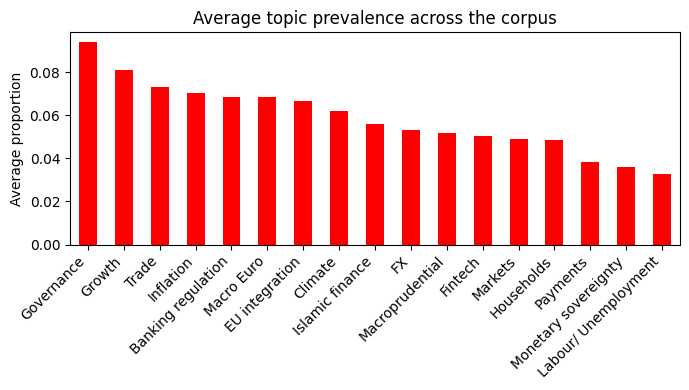

In [136]:
topic_labels = {
    "topic_0": "Banking regulation",
    "topic_1": "EU integration",
    "topic_2": "Governance",
    "topic_3": "Markets",
    "topic_4": "Islamic finance",
    "topic_5": "Macro Euro",
    "topic_6": "Inflation",
    "topic_7": "Climate",
    "topic_8": "Macroprudential",
    "topic_9": "Trade",
    "topic_10": "Households",
    "topic_11": "Labour/ Unemployment",
    "topic_12": "Growth",
    "topic_13": "Payments",
    "topic_14": "Fintech",
    "topic_15": "FX",
    "topic_16": "Monetary sovereignty"
}


topic_cols = [f"topic_{i}" for i in range(17)]

topic_means = df[topic_cols].mean()
topic_means.index = [topic_labels[col] for col in topic_means.index]
topic_means = topic_means.sort_values(ascending=False)
plt.figure(figsize=(7,4))
topic_means.plot(kind="bar", color="red")
plt.title("Average topic prevalence across the corpus")
plt.ylabel("Average proportion")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


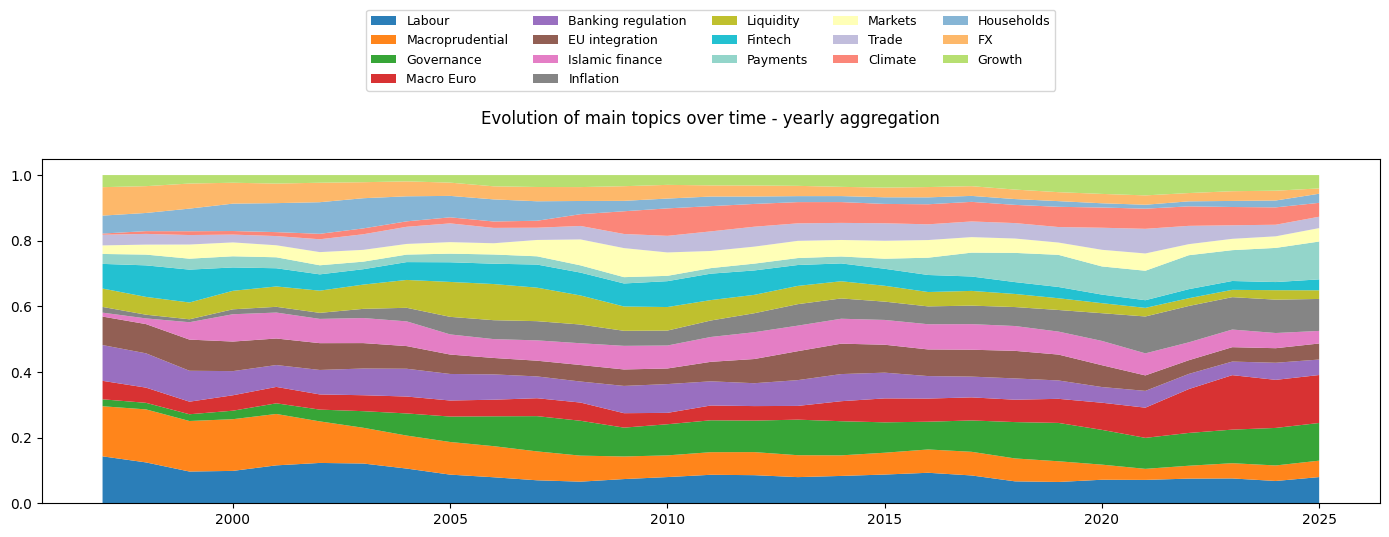

In [ ]:
# LDA topic distribution over time - yearly aggregation + smoothing + top topics visualization

lda_output = lda.transform(tf)
for i in range(lda_output.shape[1]):
    df[f"topic_{i}"] = lda_output[:, i]
df["date"] = pd.to_datetime(df[["Year", "Month"]].assign(day=1))
df["year"] = df["date"].dt.year
topic_cols = [col for col in df.columns if col.startswith("topic_")]
df_time = df.groupby("year")[topic_cols].mean()
top_topics = df_time.mean().sort_values(ascending=False).head(17).index
df_time = df_time[top_topics]
df_time = df_time.rolling(2, min_periods=1).mean()
topic_labels = {
    "topic_0": "Banking regulation",
    "topic_1": "EU integration",
    "topic_2": "Governance",
    "topic_3": "Markets",
    "topic_4": "Liquidity",
    "topic_5": "Islamic finance",
    "topic_6": "Macro Euro",
    "topic_7": "Inflation",
    "topic_8": "Climate",
    "topic_9": "Macroprudential",
    "topic_10": "Trade",
    "topic_11": "Households",
    "topic_12": "Labour",
    "topic_13": "Growth",
    "topic_14": "Payments",
    "topic_15": "Fintech",
    "topic_16": "FX"
}

labels = [topic_labels[t] for t in df_time.columns]

n_topics = df_time.shape[1]
colors = (
    list(plt.get_cmap("tab10").colors) +
    list(plt.get_cmap("Set3").colors) +
    list(plt.get_cmap("Dark2").colors)
)[:n_topics]
plt.figure(figsize=(14,6))
plt.stackplot(
    df_time.index,
    df_time.T,
    labels=labels,
    colors=colors,
    alpha=0.95
)

plt.xticks(rotation=0)
plt.title("Evolution of main topics over time - yearly aggregation", pad=25)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.45),
    ncol=5,
    fontsize=9
)

plt.tight_layout()
plt.show()